# Answers :  Stable Diffusion V3 

In [54]:
%pip install torch diffusers clip datasets

In [55]:
from diffusers.models.autoencoders.autoencoder_kl import AutoencoderKL
import torch
import torch.nn as nn 
import torch.nn.functional as F 
from datasets import load_dataset
import math
import numpy as np
from transformers import CLIPTokenizer, CLIPTextModel
import types



#### I accidentally made stable diffusion v3 lol i looked up and it seems i made the latest version when i replaced Unet with DiT except that it does not have rectified flow but DDIM/DDPM 
older title before i realized it : 
#### "Stable Diffusion V1 (Diffusion Transformer) Hybrid Version"

*Weird flex but ok*

the training pipeline for stable diffusion v1 is basically:
- Pretrained Hybrid VAE Self Attention based model
    - input image -> downsample -> resnet blocks -> self attn blocks -> resnet -> self attention blocks again -> resnet -> z $(z=\mu+\sigma)$ -> resnet -> self attn -> resnet -> upsample -> group norm -> final conv -> image $[B,C,P_x,P_y]$
    - loss function for this VAE's pretraining :
        $$L_{\text{VAE}} =\underbrace{\|x-\hat{x}\|_1}_{\text{reconstruction}} + \underbrace{\lambda_{\text{kl}}\,D_{\text{KL}}\!\left(q(z|x)\,\|\,\mathcal N(0,1)\right)}_{\text{KL loss}} + \underbrace{\lambda_{\text{percep}}\sum_j \|\phi_j(x)-\phi_j(\hat{x})\|_2^2}_{\text{perceptual loss (pretrained VGG)}} + \underbrace{\lambda_{\text{adv}}\max\!\left(0,1-D(\hat{x})\right)}_{\text{adversarial loss (PatchGAN discriminator)}}$$
        $$ L_{\text{perceptual}} =\sum_j \frac{1}{C_j H_j W_j}\,\|\phi_j(x)-\phi_j(\hat{x})\|_2^2$$
         -> we have a pretrained VGG that grades a judge to vae's decoder if it feels 'anatomical' or good enough without paying much attention to fine texture details, this makes latent space richer 
        we also do GAN training on VAE with a discrimantor being PatchGAN, we throw away patchgan when we're done training, since we want the generator i.e VAE decoder
        $$ L_{\text{discriminator}} = \mathbb{E}_{x}\big[\max(0, 1 - D(x))\big] + \mathbb{E}_{z}\big[\max(0, 1 + D(G(z)))\big]$$
        $$L_{\text{generator} = - \mathbb{E}_{A}[D(\hat{x})]}

    - we use vae encoder only during training stable diffusion and vae decoder during inference 


Encode image to VAE Encoder
Get z [BCHW]
add sampled $\epsilon ~ \mathcal(N)$ from normal distribution by DDPM : $$\underset{\text{noisy latent}}{z_t} = \underset{\text{scales down original image}}{\underset{\text{curve}}{\sqrt{\hat{\alpha_T}}}z_0} + \underset{\text{scales up random noise}}{\sqrt{1-\hat{\alpha_t}}}\underset{\text{random gaussian noise}}{\epsilon}$$

$\alpha_t = 1 - \beta_t$ : how much original image is preserved 
$\alpha_t$ cumulative product from to step t (linear or cosine)

we now split in two ways path a and path b.

Path A: latent path
- take noisy latent $z_t$
- Patchify A
- Linear layer
- 2D sinsonidal Positional encoding  
- get image token 

Path B: Conditioning path
- take the time of noisy latent ${z_t}$

subpath 1: temporal context ( time )
- 1d sinsonidal positional encoding
- MLP (Swiglu)
- time vector 

subpath 2: semantic context (clip)
- get class of the image or text prompt from dataset
- tokenize 
- linear embedding learnable or CLIP for text prompt
- class vector 

merge class vector + time vector -> $y_{\text{instruction}}$ vector 


now merge $y_{\text{instruction}}$ + image token

pass through AdaLN-zero : "steer patches by instruction" : 
- get yinstruction vector 
- pass through linear layer 
- get $\gamma_1, \beta_1, \beta_1, \alpha_1, \gamma_2, \beta_2, \beta_2, \alpha_2$
- where gamma 1 and beta 1 is for scale shifting for attn layer, gamma 2 beta 2 is for scale sifting for MLP layer and alpha 1 and alpha 2 are gates for importance 

then self attn

then FFN MLP

then linear decoder 

then unpatchify

then get final predicted noise $\hat{\epsilon}$


now calculate loss with predicted epsilon and original epsilon we used during adding noise to latent image 



however during inference we use DDIM to reduce subtract the noise from current z_t and then keep going backwards deterministically of predicting and removing noise 

we use CFG classifier free guidance concept where we get model to produce two outputs in eval mode where one is conditioned on our prompt and other not on our prompt and then combine 

- conditioned: $(\epsilon_{\text{cond}}=\epsilon_\theta(x_t,t,c))$
- unconditioned: $(\epsilon_{\text{uncond}}=\epsilon_\theta(x_t,t,\varnothing))$

Then combine:
$$
\epsilon_{\text{guided}}=\epsilon_{\text{uncond}}+w(\epsilon_{\text{cond}}-\epsilon_{\text{uncond}})
$$
- $(w=1)$: normal conditional prediction
- $(w>1)$: stronger prompt alignment, but can oversaturate/artifact
- $(w=0)$: unconditional generation

and so that w is called as guidance scale so that we can control how strongly it aligns to our prompt 

DDPM sampling is stochastic reverse process (adds randomness each step)
DDIM sampling is deterministic path where it uses predicted noise to estimate z_0 then computes z_t-1 directly on a consistent trajectory 

then we finally convert the final latent back into image using attn_vae decoder



## Preparing easy dataset

In [56]:
ds = load_dataset("reach-vb/pokemon-blip-captions")

In [ ]:
from torch.utils.data import DataLoader

def load_batch(batch):
    # collate image tensor + caption text for conditional training
    images, texts = [], []
    for item in batch:
        img = item['image'].convert('RGB').resize((32, 32))
        img_array = np.array(img)
        #  H,W,C) -> (C,H,W), normalize to [-1,1] for SD VAE
        img_tensor = torch.tensor(img_array, dtype=torch.float32).permute(2, 0, 1) / 255.0
        img_tensor = img_tensor * 2.0 - 1.0
        images.append(img_tensor)
        caption = item.get('text', item.get('caption', ''))
        texts.append(str(caption))
    return torch.stack(images), texts



In [58]:
train_data = ds['train']
train_loader = DataLoader(train_data, batch_size=2, shuffle=True, collate_fn=load_batch)


### LPIPS + Self Attention based VAE

#### Pretrained VAE

this VAE has self attention blocks in between to deal with latent z  

In [59]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [60]:
# get pretrained VAE 
# attn_vae = AutoencoderKL.from_pretrained(
#     "CompVis/stable-diffusion-v1-4", 
#     subfolder="vae",
#     torch_dtype=torch.float16  
# ).to("cuda")

## Stable Diffusion

#### LatentImage Embedding

in classification models we keep CLS token and throw away patches after learning
but in generative models, we dont keep CLS token at all since we're trying to predict noise and recon the image

$$\text{Num of Patches} = \frac{HW}{P^2}$$


Path A: latent path
- take noisy latent $z_t$
- Patchify A
- Linear layer
- 2D sinsonidal Positional encoding  
- get image token 

In [61]:
class LatentImageEmbedding(nn.Module):
    # forms path a for image embedding
    def __init__(self, in_dim, out_dim, embed_dim, patch_size=2, patch_width=32, patch_height=32):
        super().__init__()
        self.patch_size = patch_size
        self.embed_dim = embed_dim
        self.patch_width = patch_width
        self.patch_height = patch_height
        # proj expects input of size patch_dim (= C*P*P) and outputs out_dim
        self.proj = nn.Linear(in_dim, out_dim)
        
    def forward(self, x):
        # x is noisy latent here
        B, C, H, W = x.shape
        P = self.patch_size
        # # number of patches along height/width
        h_p = H // P
        w_p = W // P
        # patchify (B, C, H/P, W/P, P, P)
        x = x.unfold(2, P, P).unfold(3, P, P)
        x = x.permute(0, 2, 3, 1, 4, 5).contiguous()
        # reshape to (B, N, patch_dim)
        N = h_p * w_p
        patch_dim = C * P * P
        x = x.view(B, N, patch_dim)
        # project to token dimension (B, N, out_dim)
        x = self.proj(x)
        # add 2d sinusoidal positional embedding (N, out_dim) -> expand to (B,N,out_dim)
        pe = self.sinsonidal_embedding_2d(h_p, w_p).to(x.device)
        x = x + pe.unsqueeze(0)
        return x

    def sinsonidal_embedding_2d(self, h_p, w_p):
        device = next(self.proj.parameters()).device if hasattr(self, 'proj') else torch.device('cpu')
        half_dim = self.embed_dim // 2
        # we use div term for uniqueness id
        div_term = torch.exp(torch.arange(0, half_dim, 2, device=device).float() * (-math.log(10000.0) / (half_dim)))
        # vertical y sine half and cos half wave
        pos_y = torch.arange(h_p, device=device).unsqueeze(1).float()
        pe_y = torch.zeros(h_p, half_dim, device=device)
        pe_y[:, 0::2] = torch.sin(pos_y * div_term)
        pe_y[:, 1::2] = torch.cos(pos_y * div_term)
        
        # horizontal x sine half and cos half wave
        pos_x = torch.arange(w_p, device=device).unsqueeze(1).float()
        pe_x = torch.zeros(w_p, half_dim, device=device)
        pe_x[:, 0::2] = torch.sin(pos_x * div_term)
        pe_x[:, 1::2] = torch.cos(pos_x * div_term)
        pe_y = pe_y.view(h_p, 1, half_dim).repeat(1, w_p, 1)
        pe_x = pe_x.view(1, w_p, half_dim).repeat(h_p, 1, 1)
        pe_2d = torch.cat([pe_y, pe_x], dim=-1).view(h_p * w_p, self.embed_dim)
        # (N, embed_dim) where N = h_p * w_p
        return pe_2d

#### TimeEmbedding + Class/Text Embedding

Path B: Conditioning path
- take the time of noisy latent ${z_t}$

subpath 1: temporal context ( time )
- 1d sinsonidal positional encoding
- MLP (Swiglu)
- time vector 

subpath 2: semantic context (clip)
- get class of the image or text prompt from dataset
- tokenize 
- linear embedding learnable or CLIP for text prompt
- class vector 


In [62]:
class SwigLUMLP(nn.Module):
    def __init__(self, model_dim, d_ff):
        # uses swiglu activation function 
        super().__init__()
        self.w1 = nn.Linear(model_dim, d_ff, bias=False) 
        self.w2 = nn.Linear(model_dim, d_ff, bias=False) 
        self.w3 = nn.Linear(d_ff, model_dim, bias=False) 
    def forward(self, x):
        return self.w3(F.silu(self.w1(x)) * self.w2(x))


In [63]:
class TextEmbedding(nn.Module):
    # pass text prompt or accept tensor inputs and return an embed vector
    def __init__(self, embed_dim):
        super().__init__()
        self.tokenizer = CLIPTokenizer.from_pretrained("openai/clip-vit-base-patch32")
        self.embedding = CLIPTextModel.from_pretrained("openai/clip-vit-base-patch32")
        # project CLIP hidden size to requested embed_dim
        hidden_size = self.embedding.config.hidden_size if hasattr(self.embedding, 'config') else embed_dim
        self.project = nn.Linear(hidden_size, embed_dim)
        self.out_dim = embed_dim

    def forward(self, x):
        tokens = self.tokenizer(x, return_tensors="pt", padding=True, truncation=True)
        device = next(self.embedding.parameters()).device
        tokens = {k: v.to(device) for k, v in tokens.items()}
        out = self.embedding(**tokens).last_hidden_state
        out = out.mean(dim=1)
        return self.project(out)

In [64]:
class TimeEmbedding(nn.Module):
    # apply 1D sinusoidal positional encoding and pass through SwiGLU MLP
    def __init__(self, d_ff, embed_dim):
        super().__init__()
        self.embed_dim = embed_dim 
        # use embed_dim as input dim for MLP so shapes match
        self.mlp = SwigLUMLP(embed_dim, d_ff)

    def forward(self, t):
        # t: (B,) or scalar
        if isinstance(t, int):
            t = torch.tensor([t])
        t = torch.as_tensor(t).to(next(self.mlp.w1.parameters()).device).float()
        if t.dim() == 0:
            t = t.unsqueeze(0)
        
        B = t.shape[0]
        # compute frequencies for embed_dim 
        i = torch.arange(0, self.embed_dim, 2, device=t.device).float()
        frequencies = torch.exp(i * (-math.log(10000.0) / self.embed_dim))
        
        # (B, 1) @ (embed_dim/2,) -> (B, embed_dim/2)
        position = t.unsqueeze(1)  # (B, 1)
        args = position * frequencies  # (B, embed_dim/2)
        
        # build sinusoid embeddings
        pe = torch.zeros(B, self.embed_dim, device=t.device)
        pe[:, 0::2] = torch.sin(args)
        pe[:, 1::2] = torch.cos(args)
        
        return self.mlp(pe)  # (B, embed_dim)


In [65]:
class ConditioningEmbedding(nn.Module):
    # pass through time embedding and text embedding, sum and return
    def __init__(self, d_ff, embed_dim):
        super().__init__()
        self.text_embedding = TextEmbedding(embed_dim)
        self.time_embedding = TimeEmbedding(d_ff, embed_dim)
        self.embed_dim = embed_dim

    def forward(self, t, x):
        # t timestep (B,) or scalar
        # x text prompt(s)
        temporal_context = self.time_embedding(t)  # (B, embed_dim)
        semantic_context = self.text_embedding(x)  # (B, embed_dim)
        return temporal_context + semantic_context  # (B, embed_dim)


#### AdaLN

pass through AdaLN-zero : "steer patches by instruction" : 
- get yinstruction vector 
- pass through linear layer 
- get $\gamma_1, \beta_1, \beta_1, \alpha_1, \gamma_2, \beta_2, \beta_2, \alpha_2$
- where gamma 1 and beta 1 is for scale shifting for attn layer, gamma 2 beta 2 is for scale sifting for MLP layer and alpha 1 and alpha 2 are gates for importance 


In [66]:
class AdaLNZero(nn.Module):
    # inject timestep and class embedding
    def __init__(self, embed_dim):
        super().__init__()
        # 6 parameters per block, gamma1, gamma2, alpha1, alpha2, beta1, beta2
        self.linear = nn.Linear(embed_dim, 6 * embed_dim)
        # start as zeros for stability
        nn.init.zeros_(self.linear.weight)
        nn.init.zeros_(self.linear.bias)
    def forward(self, y_cond): 
        # y_cond (B, D) -> (B,1,D) for broadcasting over tokens
        parts = self.linear(y_cond).chunk(6, dim=1)
        beta_attn, gamma_attn, alpha_attn, beta_ml, gamma_mlp, alpha_mlp = parts
        return beta_attn.unsqueeze(1), gamma_attn.unsqueeze(1), alpha_attn.unsqueeze(1), beta_ml.unsqueeze(1), gamma_mlp.unsqueeze(1), alpha_mlp.unsqueeze(1)

#### DiT Block (Gated attention via Adalnzero)

$$\text{LN}(x) = \gamma \left( \frac{x - \mu}{\sigma} \right) + \beta$$

$$\text{AdaLN}(x, c) = \gamma(c) \cdot \text{LayerNorm}(x) + \beta(c)$$

where c is timestep emebedding or conditioning vector

then res equation becomes 

$$ \text{res} = (\gamma \left( \frac{x - \mu}{\sigma} \right) + \beta ) * (1 + \gamma_\text{adz}) + \beta_\text{adz} $$

therefore skip connection:

$$ x = x + \alpha * \text{MLP}(res)$$
$$ x = x + \alpha * \text{Attn}(res)$$

or basically 


$$ x = x + \alpha * \text{Block}( (\gamma_\text{ln} \left( \frac{x - \mu}{\sigma} \right) + \beta_\text{ln} ) * (1 + \gamma_\text{adz}) + \beta_\text{adz} )$$

just for reference 

$$\text{Multi Head Self Attention(Q,K,V)} = (\frac{Q.K^T}{\sqrt{d_\text{model}}})V$$

where its bidirectional attention instead of masked attention becuase here we want model to be a 'denoising' refiner, not an autoregressive generator, we are feeding it already a fully noise image at once, 

pass through AdaLN-zero : "steer patches by instruction" : 
- get yinstruction vector 
- pass through linear layer 
- get $\gamma_1, \beta_1, \beta_1, \alpha_1, \gamma_2, \beta_2, \beta_2, \alpha_2$
- where gamma 1 and beta 1 is for scale shifting for attn layer, gamma 2 beta 2 is for scale sifting for MLP layer and alpha 1 and alpha 2 are gates for importance 


In [67]:
class DiT(nn.Module):
    # get adaln output
    # apply layernorm using adaln for attn output 
    # apply layernorm using adaln for mlp output
    def __init__(self, embed_dim, num_heads):
        super().__init__() 
        self.norm1 = nn.LayerNorm(embed_dim, elementwise_affine=False)
        self.attn = nn.MultiheadAttention(embed_dim, num_heads, batch_first=True)
        self.norm2 = nn.LayerNorm(embed_dim, elementwise_affine=False)
        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, 4 * embed_dim),
            nn.GELU(),
            nn.Linear(4 * embed_dim, embed_dim)
        )
        self.adaLNZero = AdaLNZero(embed_dim)
    
    def forward(self, x, y_cond):
        # x image tokens (B, N, D)
        # y_cond conditioning vector (B, D)
        beta_attn, gamma_attn, alpha_attn, beta_mlp, gamma_mlp, alpha_mlp = self.adaLNZero(y_cond)
        # Attn block
        res = self.norm1(x) * (1 + gamma_attn) + beta_attn # scale and shift
        attn_out, _ = self.attn(res, res, res)
        x = x + alpha_attn * attn_out # gated importance
        # MLP block
        res = self.norm2(x) * (1 + gamma_mlp) + beta_mlp
        mlp_out = self.mlp(res)
        x = x + alpha_mlp * mlp_out
        return x


#### Setting this up

$$\text{Unpatchifying sequence} = C * P^2$$
where c is channels

In [68]:
class Model(nn.Module):
    def __init__(self, embed_dim, latent_image_patch_size, latent_image_patch_width, latent_image_patch_height, latent_image_proj_in_dim, latent_image_proj_out, d_ff, num_heads, out_channels, device):
        super().__init__()
        self.dit_adalnzero = DiT(embed_dim, num_heads)
        self.device = device
        # use embed_dim for conditioning so dims line up
        self.conditioning_embedding = ConditioningEmbedding(d_ff, embed_dim)
        self.latent_image_patch_size = latent_image_patch_size
        self.latent_image_patch_width = latent_image_patch_width
        self.latent_image_patch_height = latent_image_patch_height
        self.latent_image_embedding = LatentImageEmbedding(latent_image_proj_in_dim, latent_image_proj_out, embed_dim, latent_image_patch_size, latent_image_patch_width, latent_image_patch_height)
        # decoder maps token dim (embed_dim) to patch output channels (out_channels)
        self.linear_decoder = nn.Linear(embed_dim, out_channels)


    def unpatchify(self, x, h_p=None, w_p=None):

        # x: (B, N, C*P*P) where N = h_p * w_p

        B, N, patch_dim = x.shape
        P = self.latent_image_patch_size
        c = patch_dim // (P * P)

        # (B, N, C*P*P) -> (B, h_p, w_p, C, P, P)
        x = x.view(B, h_p, w_p, c, P, P)
        
        # (B, h_p, w_p, C, P, P) -> (B, C, h_p, P, w_p, P)
        x = x.permute(0, 3, 1, 4, 2, 5).contiguous()

        # (B, C, h_p, P, w_p, P) -> (B, C, H, W)
        return x.view(B, c, h_p * P, w_p * P)

    def forward(self, x, t, text=None):

        P = self.latent_image_patch_size
        h_p = x.shape[2] // P
        w_p = x.shape[3] // P

        # get noised z 
        # pass through path a : latent image embedding + path b conditioning embeddings (time + text)
        image_tokens = self.latent_image_embedding(x)  # (B, N, embed_dim)
        
        # if text provided, use it; otherwise use empty string for unconditional
        if text is None:
            text = ""
        
        # get conditioning vector from timestep and text
        y_cond = self.conditioning_embedding(t, text)  # (B, embed_dim)

        # pass through DiT with conditioning
        y_out = self.dit_adalnzero(image_tokens, y_cond)  # (B, N, embed_dim)
        
        # pass through linear decoder 
        x = self.linear_decoder(y_out)  # (B, N, out_channels)
        
        # unpatchify
        eps_hat = self.unpatchify(x, h_p=h_p, w_p=w_p)
        # return predicted noise (B,C,H,W)
        return eps_hat


#### Model Class

In [69]:
class StableDiffusion:
    def __init__(self):
        self.device = "cuda" if torch.cuda.is_available() else "cpu"
        C, P = 4, 2
        patch_h, patch_w = 16, 16
        patch_dim = C * P * P
        embed_dim = 64
        self.model = Model(embed_dim=embed_dim, latent_image_patch_size=P, latent_image_patch_width=patch_w, latent_image_patch_height=patch_h, latent_image_proj_in_dim=patch_dim, latent_image_proj_out=embed_dim, d_ff=256, num_heads=4, out_channels=patch_dim, device=self.device)
        self.model.to(self.device)
        self.optimizer = torch.optim.AdamW(params=self.model.parameters(), lr=1e-4)
        self.loss_fn = nn.MSELoss()
        self.attn_vae = AutoencoderKL.from_pretrained("CompVis/stable-diffusion-v1-4", subfolder="vae").to(self.device)
        self.attn_vae.eval()
        self.timesteps = 50
        self.latent_shape = None
        
    def schedular(self, timesteps, batch_size=1):
        # return random timesteps for the batch
        return torch.randint(0, timesteps, (batch_size,), device=self.device)

    # sample noise and add it to latent image z 
    def apply_ddpm(self, z, t, timesteps=50):
        pass
    
    def apply_ddim(self, x_t, t, t_prev, eps_pred, timesteps=50):
        pass
    
    def train(self, train_loader, timesteps=50, epochs=50, cfg_dropout=0.1):
        # pass images through vae to get latent z 
        self.model.train()
        self.attn_vae.eval()
        for epoch in range(epochs):
            epoch_loss = 0.0
            num_batches = 0
            for _, batch in enumerate(train_loader):
                # batch from collate_fn: (image tensor, list[str] captions)
                image, text = batch
                    
                self.optimizer.zero_grad(set_to_none=True)
                image = image.to(self.device)
                
                # get latent image
                with torch.no_grad():
                    encoded = self.attn_vae.encode(image)
                    z = encoded.latent_dist.sample().to(self.device)
                    z = z * self.attn_vae.config.scaling_factor
                    if self.latent_shape is None:
                        self.latent_shape = tuple(z.shape[1:])
                
                # sample random timesteps for the batch
                t = self.schedular(timesteps, batch_size=z.shape[0])
                
                # sample noise and add it to latent image z 
                z_t, eps = self.apply_ddpm(z, t, timesteps=timesteps)
                
                # classifier-free guidance training: randomly drop conditioning text
                text_cond = [txt if np.random.rand() > cfg_dropout else "" for txt in text]
                # pass noised image + timestep + text through model
                eps_hat = self.model(z_t, t, text=text_cond)
                
                # compare eps with eps_hat on MSE
                loss = self.loss_fn(eps, eps_hat)
                # backprop
                loss.backward()
                torch.nn.utils.clip_grad_norm_(self.model.parameters(), 1.0)
                
                self.optimizer.step()
                epoch_loss += loss.item()
                num_batches += 1
            
            print(f"Epoch {epoch + 1}/{epochs}, Avg Loss: {epoch_loss / max(1, num_batches):.4f}")
        
    def eval(self, text="", conditioning_scale=4.0, seed=None, timesteps=None, num_inference_steps=20):
        
        if seed is None:
            seed = 0
        torch.manual_seed(seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(seed)
        if timesteps is None:
            timesteps = self.timesteps
        
        self.model.eval()
        if self.latent_shape is None:
            # fallback: infer latent shape from a 32x32 dummy image
            with torch.no_grad():
                dummy = torch.zeros(1, 3, 32, 32, device=self.device)
                dummy_z = self.attn_vae.encode(dummy).latent_dist.sample().to(self.device)
                dummy_z = dummy_z * self.attn_vae.config.scaling_factor
                self.latent_shape = tuple(dummy_z.shape[1:])
        # start with random latent noise in the same shape used during training
        x_t = torch.randn(1, *self.latent_shape, device=self.device)
        t_schedule = torch.linspace(timesteps - 1, 0, num_inference_steps, device=self.device).long()
        
        for i in range(num_inference_steps):
            t = t_schedule[i].view(1)
            t_prev = t_schedule[i + 1].view(1) if i < num_inference_steps - 1 else torch.zeros(1, dtype=torch.long, device=self.device)
            
            with torch.no_grad():
                # if unconditioned, skip CFG branch
                if (text is None) or (isinstance(text, str) and text.strip() == "") or conditioning_scale == 0.0:
                    eps_pred = self.model(x_t, t.long(), text=[""])
                else:
                    # classifier-free guidance
                    eps_cond = self.model(x_t, t.long(), text=[text])
                    eps_uncond = self.model(x_t, t.long(), text=[""])
                    eps_pred = eps_uncond + conditioning_scale * (eps_cond - eps_uncond)
            
            # denoising step
            x_t = self.apply_ddim(x_t, t.long(), t_prev.long(), eps_pred, timesteps=timesteps)
        
        # decode latent to image
        with torch.no_grad():
            decoded = self.attn_vae.decode(x_t / self.attn_vae.config.scaling_factor)
            image = decoded.sample
        
        return image


In [70]:
stable_diffusion = StableDiffusion()

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                                            | Status     |  | 
---------------------------------------------------------------+------------+--+-
vision_model.encoder.layers.{0...11}.self_attn.out_proj.bias   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.mlp.fc1.weight            | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.out_proj.weight | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.layer_norm2.weight        | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.layer_norm1.weight        | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.layer_norm1.bias          | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.mlp.fc2.weight            | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.layer_norm2.bias          | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.self_attn.q_proj.weight   | UNEXPECTED |  | 
vision_model.encoder.layers.{0...11}.

### Training using DDPM

#### DDPM in training  



at first we take the latent image, 

we have timesteps up until $t=1,...T$, and at each step,

if we have a normal x_1 and we want to add noise to it :

$$x_1 = x_0 + \epsilon$$

this for 1000 times will explore the "variance" of the data

so what we do is try to keep total "variance" of the data the same while adding gaussian noise

so as to do this we use pythagorean identity 
$$a^2+b^2 = 1$$

where if we treat a^2 as data anb b as gaussian noise and solve for b

we get

$$x^2 = 1 - b^2$$

therefore:

$$x = \sqrt{1-\beta}$$

where beta is our tiny gaussian noise per step

that is how we get 

$$x_1 = \sqrt{1-\beta}*x_0 + \sqrt{\beta}*\epsilon $$

where $\sqrt{1-\beta}$ is the "shrinkage", this pulls $x_0$ slightly towards zero basically that means how much noise is added to x  or how much info we preserve

while $\sqrt{\beta}$ is the noisy weight itself

because $(\sqrt{1-\beta})^2 + (\sqrt{\beta})^2 = 1$ the total variance of x_1 remains exactly same as x_0, we hae swapped a tiny bit of data or x from original pythagorean equation for a tiny bit of noise without changing the scale

if we want to add noise to each data point one by one

*1'st step:*

$x_1 = \sqrt{1-\beta_1}*x_0 + \sqrt{\beta_1}*\epsilon_0 $ or $x_1 = \sqrt{\alpha_1}*x_0 + \sqrt{1-\alpha_1}*\epsilon_0 $

*2'nd step:*

$x_2 = \sqrt{1-\beta_1}*x_1 + \sqrt{\beta_2}*\epsilon_1 $ or $x_2 = \sqrt{\alpha_2}*x_1 + \sqrt{1-\alpha_2}*\epsilon_1 $


this is very computationally bad

but we use reparameterization trick:

what if we use 1st step's x_1 equation in step 2nd's x_2's equation substitution?

$x_1 = \sqrt{\alpha_1}*x_0 + \sqrt{1-\alpha_1}*\epsilon_0 $

replace this in x_2

we get:
$x_2 = \sqrt{\alpha_2}*x_1 + \sqrt{1-\alpha_2}*\epsilon $

$x_2 = \sqrt{\alpha_2}* (\sqrt{\alpha_1}*x_0 + \sqrt{1-\alpha_1}*\epsilon) + \sqrt{1-\alpha_2}*\epsilon $

$x_2 = \sqrt{\alpha_2}\sqrt{\alpha_1}x_0 + \sqrt{\alpha_2}\sqrt{1-\alpha_1 \epsilon_0} + \sqrt{1-\alpha_2}\epsilon_1 $

$x_2 = \sqrt{\alpha_2 \alpha_1}x_0 + \sqrt{\alpha_2}\sqrt{1-\alpha_1 \epsilon_0} + \sqrt{1-\alpha_2}\epsilon_1 $

here we know that 
$$x_2 = \underset{\text{signal part}}{\sqrt{\alpha_2 \alpha_1}x_0} + \underset{\text{noise 1 part + noise 2 part}}{\sqrt{\alpha_2 (1-\alpha_1) \epsilon_0}+ \sqrt{1-\alpha_2}\epsilon_1} $$


since sum of gaussains is a gaussian itself, we can combine all and say

$$\eta = \sqrt{\alpha_2 (1-\alpha_1) \epsilon_0}+ \sqrt{1-\alpha_2}\epsilon_1$$


$$x_2 = \sqrt{\alpha_1 \alpha_2}x_0 + \eta$$

If $\epsilon\sim\mathcal N(0,I)$, then $\epsilon\sim\mathcal N(0,c^2 I)$

Scaling by $(c)$ multiplies variance by $(c^2)$


$\eta = \sqrt{\alpha_2 (1-\alpha_1) \epsilon_0}+ \sqrt{1-\alpha_2}\epsilon_1$

since $\epsilon_0$ and $\epsilon_1$ are independent, with variance $I$

$ \text{Var}(\eta) = \sqrt{\alpha_2 (1-\alpha_1) \epsilon_0}I+ \sqrt{1-\alpha_2}\epsilon_1 I $

$= [{\alpha_2 (1-\alpha_1) \epsilon_0}+ {1-\alpha_2}\epsilon_1] I$ 

$= (1-\alpha_1\alpha_2) I$ 

therefor that means $\sqrt{1-\alpha_1\alpha_2}\epsilon$, $\epsilon ~ \mathcal{N}(0,1)$

so now we replace $\eta$ by :

$\eta = \sqrt{1-\alpha_1\alpha_2}\epsilon$

$$x_2 = \sqrt{\alpha_1 \alpha_2}x_0 + \eta$$

$$x_2 = \sqrt{\alpha_1 \alpha_2}x_0 + \sqrt{1-\alpha_1\alpha_2}\epsilon$$

therefore if we keep doing this then : 

$$x_3 = \sqrt{\alpha_1 \alpha_2 \alpha_3}x_0 + \sqrt{1-\alpha_1\alpha_2 \alpha_3}\epsilon$$
...

there for timesteps t, we can say that

$$q(x_t|x_{t-1}) = \mathcal{N}(\sqrt{1-\beta_t}x_{t-1},\beta_tI)$$

$$\bar\alpha_t:=\prod_{s=1}^t\alpha_s$$

then,

$$x_t=\sqrt{\bar\alpha_t}x_0+\sqrt{1-\bar\alpha_t}\epsilon$$


noise is added to an image using a "reparameterization trick" that allows to jump directly from a clean image ($x_0$) to a noisy version at any timestep $t$.


$$x_t = \sqrt{\bar{\alpha}_t} x_0 + \sqrt{1 - \bar{\alpha}_t} \epsilon$$
where $\epsilon$ is random Gaussian noise ($\epsilon \sim \mathcal{N}(0, I)$) and $\bar{\alpha}_t$ is a predefined value from noise schedule

#### Code

In [71]:
# sample noise and add it to latent image z 
def apply_ddpm(self, z, t, timesteps=50):
    epsilon = torch.randn_like(z)
    # linear noise schedule (beta_t increases linearly from 1e-4 to 0.02)
    betas = torch.linspace(1e-4, 0.02, timesteps, device=z.device) # linear is constantly adding noise linearly, image info is lost normally 
    # with cosine schedule we could lose gradually, retaining more info over th time  
    # alpha_t = 1 - beta_t (how much original signal is kept so far)
    alphas = 1.0 - betas
    # alpha_bar_t -> product of all alphas up to t 
    alpha_bar = torch.cumprod(alphas, dim=0)
    # get alpha_bar for this timestep t
    a_t = alpha_bar[t]
    a_t = a_t.unsqueeze(-1).unsqueeze(-1).unsqueeze(-1)
    # reparam trick :  scale original + scaled noise
    z_t = torch.sqrt(a_t) * z + torch.sqrt(1.0 - a_t) * epsilon
    return z_t, epsilon

In [72]:
stable_diffusion.apply_ddpm = types.MethodType(apply_ddpm, stable_diffusion) # method overriding

In [73]:
epochs = 50

stable_diffusion.train(train_loader, epochs=epochs)


Epoch 1/50, Avg Loss: 0.9180
Epoch 2/50, Avg Loss: 0.7419
Epoch 3/50, Avg Loss: 0.7087
Epoch 4/50, Avg Loss: 0.6801
Epoch 5/50, Avg Loss: 0.6781
Epoch 6/50, Avg Loss: 0.6995
Epoch 7/50, Avg Loss: 0.6792
Epoch 8/50, Avg Loss: 0.6787
Epoch 9/50, Avg Loss: 0.6882
Epoch 10/50, Avg Loss: 0.6665
Epoch 11/50, Avg Loss: 0.6720
Epoch 12/50, Avg Loss: 0.6796
Epoch 13/50, Avg Loss: 0.6674
Epoch 14/50, Avg Loss: 0.6725
Epoch 15/50, Avg Loss: 0.6561
Epoch 16/50, Avg Loss: 0.6727
Epoch 17/50, Avg Loss: 0.6575
Epoch 18/50, Avg Loss: 0.6455
Epoch 19/50, Avg Loss: 0.6562
Epoch 20/50, Avg Loss: 0.6699


KeyboardInterrupt: 

### Inference using DDIM

#### DDIM in inference


we can rearrange the equation 

$$x_t = \sqrt{\bar{\alpha}_t} x_0 + \sqrt{1 - \bar{\alpha}_t} \epsilon_t$$

and solve for $x_0$ by 

$\hat{x_0} = \frac{x_t - \sqrt{1 - \bar{\alpha}_t} \hat{\epsilon_t}}{\sqrt{\bar{\hat{\alpha}}_t}}$ 

this is our best guess of the clean 'latent' image at this step

DDIM builds x_s using a clean part from x_0, a direction term from epsilon_t and optional fresh random noise 


reverses the noise addition process deterministically without sampling, faster than DDPM sampling. Instead of going through all T timesteps, we can skip ahead by choosing larger $\Delta t$ steps:

$$x_{t-\Delta t} = \sqrt{\bar{\alpha}_{t-\Delta t}} \left( \frac{x_t - \sqrt{1 - \bar{\alpha}_t} \hat{\epsilon}(x_t, t)}{\sqrt{\bar{\alpha}_t}} \right) + \sqrt{1 - \bar{\alpha}_{t-\Delta t}} \hat{\epsilon}(x_t, t)$$

where $\hat{\epsilon}(x_t, t)$ is the model's predicted noise at timestep $t$, and $\Delta t$ controls how many steps we skip (larger $\Delta t$ = fewer sampling steps = faster generation). At $\Delta t = 1$ this is identical to DDPM, but larger values trade quality for speed.

$$x_s = \sqrt{\bar\alpha_s}\,\hat x_0 + \sqrt{1-\bar\alpha_s-\sigma_{t\to s}^2}\,\hat\epsilon_t + \sigma_{t\to s}z$$

CFG : $\epsilon_{final} = \hat{\epsilon}_{uncond} + \text{scale} \times (\hat{\epsilon}_{cond} - \hat{\epsilon}_{uncond})$

classifier free guidance for what noise the model should predict weighted to our prompt



In [74]:
 def apply_ddim(self, x_t, t, t_prev, eps_pred, timesteps=50):
        # one DDIM step from t to t_prev
        betas = torch.linspace(1e-4, 0.02, timesteps, device=x_t.device)
        alphas = 1.0 - betas
        alpha_bar = torch.cumprod(alphas, dim=0)
        # get alpha_bar values at current and previous timesteps
        a_t = alpha_bar[t]
        a_prev = alpha_bar[t_prev]
        # reshape for broadcasting: (B,) -> (B,1,1,1)
        a_t = a_t.unsqueeze(-1).unsqueeze(-1).unsqueeze(-1)
        a_prev = a_prev.unsqueeze(-1).unsqueeze(-1).unsqueeze(-1)
        # predict x_0 clean image from noisy x_t and predicted epsilon by subtracting
        x_0_pred = (x_t - torch.sqrt(1.0 - a_t) * eps_pred) / torch.sqrt(a_t)
        # deterministic step move to x_{t-delta_t} without added randomness
        x_prev = torch.sqrt(a_prev) * x_0_pred + torch.sqrt(1.0 - a_prev) * eps_pred
        return x_prev

In [75]:
stable_diffusion.apply_ddim = types.MethodType(apply_ddim, stable_diffusion) # method overriding

In [76]:
generated_image = stable_diffusion.eval(text="A cute pokemon", conditioning_scale=4.0, timesteps=50, num_inference_steps=50)

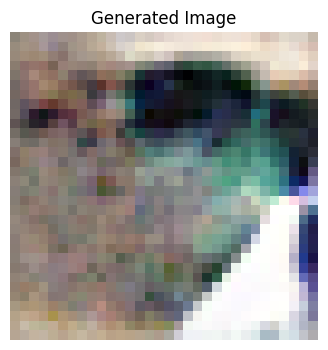

In [77]:
# Visualize generated image
import matplotlib.pyplot as plt
import torch

img = generated_image


if img.ndim == 4:
    img = img[0]
img = img.detach().float().cpu()

# CHW -> HWC for matplotlib
if img.ndim == 3:
    img = img.permute(1, 2, 0)

if img.min() < 0:
    img = (img + 1.0) / 2.0

img = torch.clamp(img, 0.0, 1.0).numpy()

plt.figure(figsize=(4, 4))
plt.imshow(img)
plt.axis('off')
plt.title('Generated Image')
plt.show()
